In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['description'] = df['description'].fillna('')

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


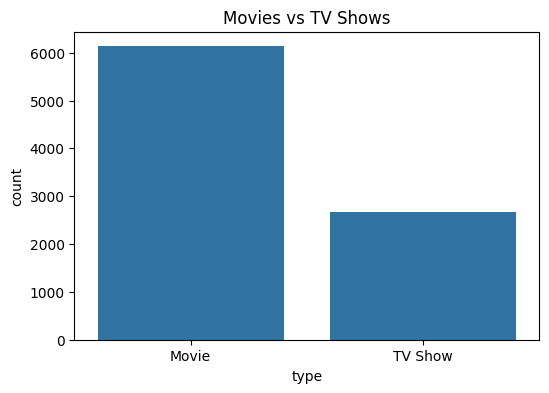

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

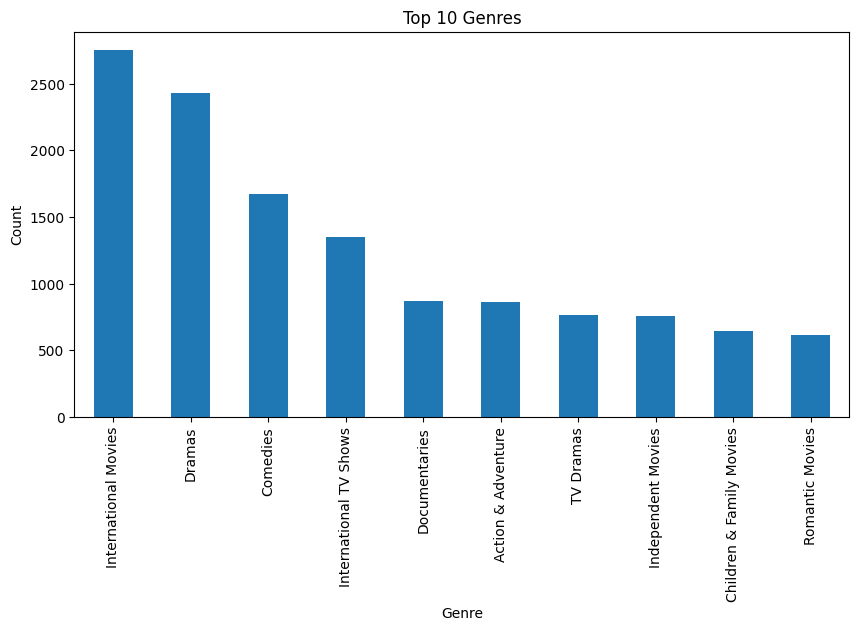

In [12]:
genre = df['listed_in'].str.split(', ').explode()

plt.figure(figsize=(10,5))
genre.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


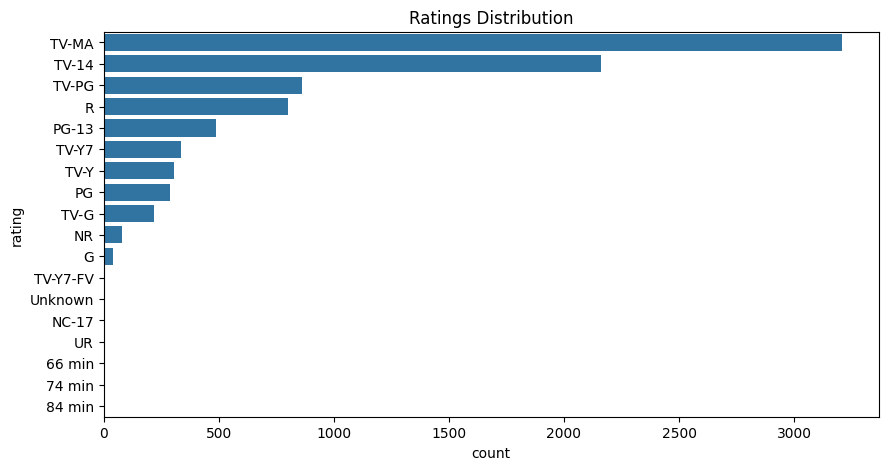

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Ratings Distribution")
plt.show()

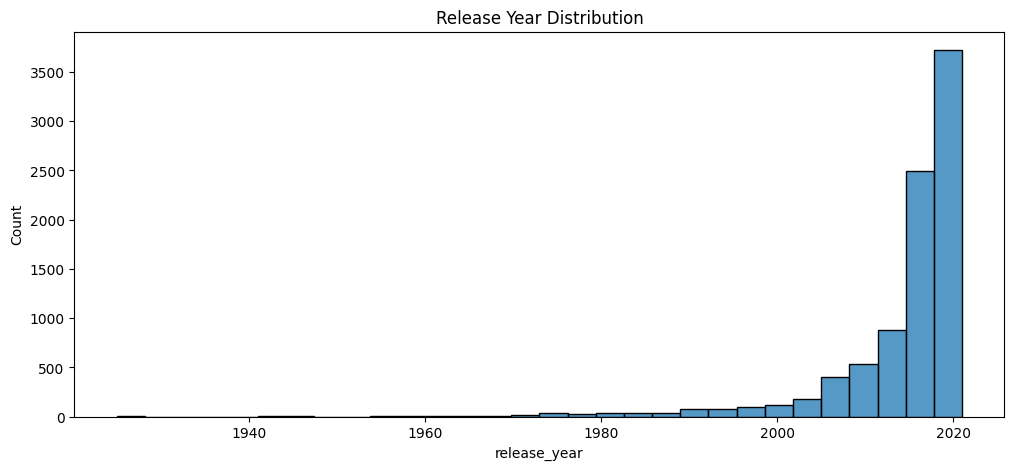

In [14]:
plt.figure(figsize=(12,5))
sns.histplot(df['release_year'], bins=30)

plt.title("Release Year Distribution")
plt.show()

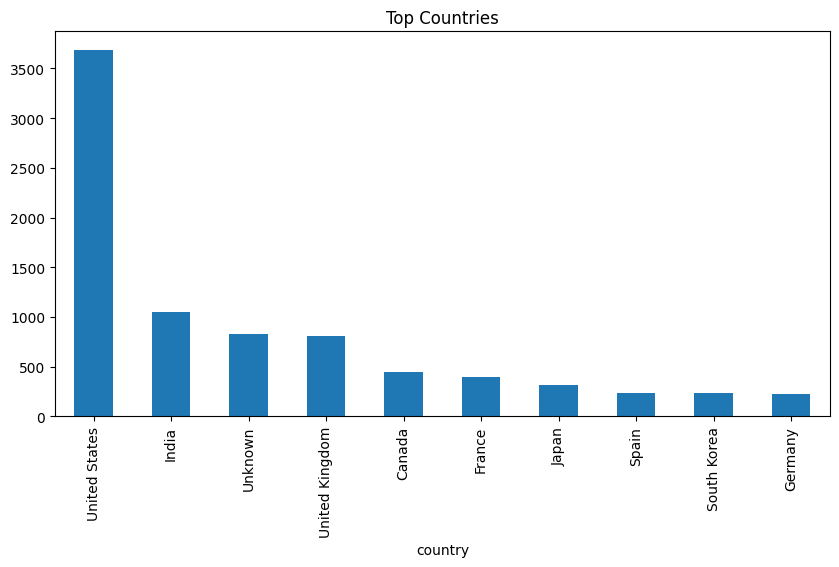

In [15]:
country = df['country'].str.split(', ').explode()

plt.figure(figsize=(10,5))
country.value_counts().head(10).plot(kind='bar')

plt.title("Top Countries")
plt.show()


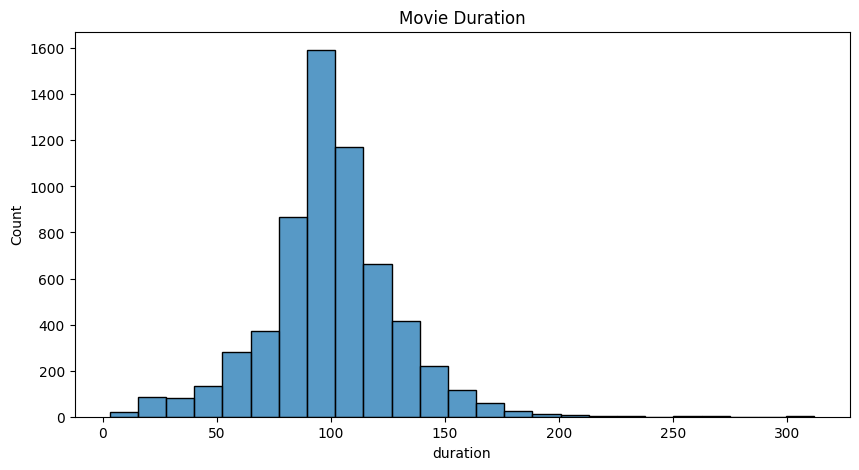

In [16]:
movies = df[df['type']=='Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')

movies['duration'] = pd.to_numeric(movies['duration'],errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(movies['duration'],bins=25)

plt.title("Movie Duration")
plt.show()

In [17]:
df['content'] = (
    df['listed_in'] + " " +
    df['description'] + " " +
    df['director'] + " " +
    df['cast']
)


In [18]:
df[['title','content']].head()

,title,content
0,Dick Johnson Is Dead,Documentaries As her father nears the end of h...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Feuds, flirtations and ..."
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


In [19]:
tfidf = TfidfVectorizer(stop_words='english')

In [20]:
tfidf_matrix = tfidf.fit_transform(df['content'])

In [21]:
tfidf_matrix.shape

(8807, 49941)

In [22]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [23]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [24]:
def recommend_movies(title, cosine_sim=cosine_sim):

    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:6]

    movie_indices = [i[0] for i in similarity_scores]

    return df[['title','listed_in']].iloc[movie_indices]

In [25]:
recommend_movies("Stranger Things")

,title,listed_in
5200,Beyond Stranger Things,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV..."
1127,Prank Encounters,"Reality TV, TV Comedies, TV Horror"
2190,The Umbrella Academy,"TV Action & Adventure, TV Mysteries, TV Sci-Fi..."
6167,Anjaan: Special Crimes Unit,"International TV Shows, TV Horror, TV Mysteries"
3398,Eli,Horror Movies


In [26]:
recommend_movies("Narcos")

,title,listed_in
3298,Wild District,"Crime TV Shows, International TV Shows, Spanis..."
6672,El Cartel,"Crime TV Shows, International TV Shows, Spanis..."
1268,El final del paraíso,"Crime TV Shows, International TV Shows, Spanis..."
7258,La Viuda Negra,"Crime TV Shows, International TV Shows, Spanis..."
2134,The Great Heist,"Crime TV Shows, International TV Shows, Spanis..."


In [27]:
recommend_movies("The Irishman")

,title,listed_in
3181,The Irishman: In Conversation,Documentaries
6880,GoodFellas,"Classic Movies, Dramas"
7820,Raging Bull,"Classic Movies, Dramas, Sports Movies"
8735,Who's That Knocking at My Door?,"Classic Movies, Dramas, Independent Movies"
7431,Mean Streets,"Classic Movies, Dramas, Independent Movies"


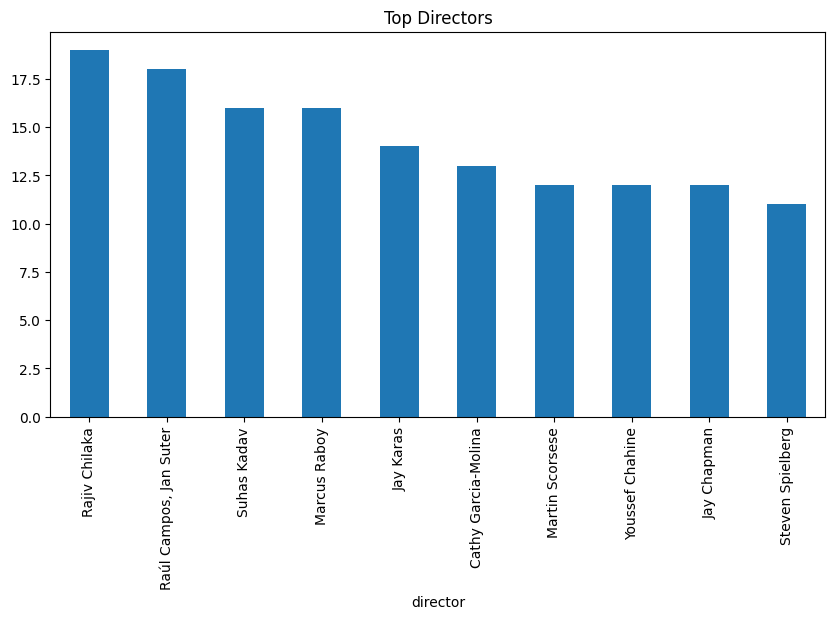

In [28]:
director = df[df['director']!='Unknown']

plt.figure(figsize=(10,5))

director['director'].value_counts().head(10).plot(kind='bar')

plt.title("Top Directors")
plt.show()

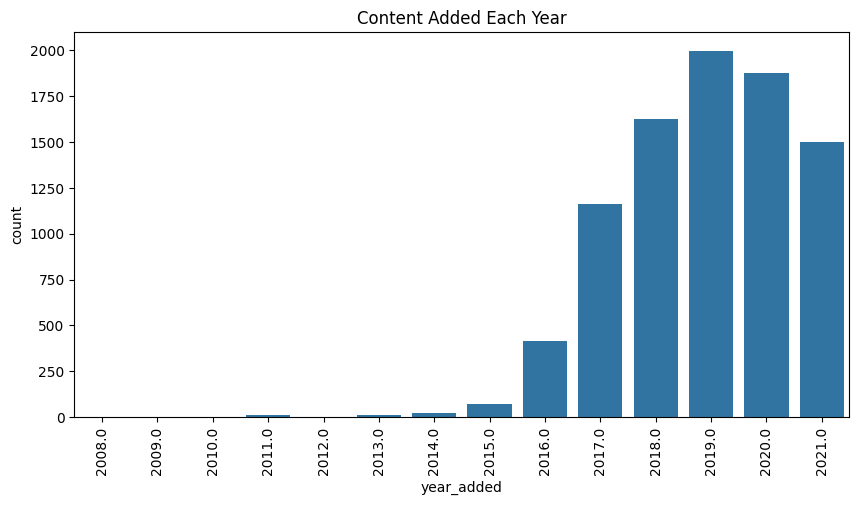

In [29]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))

sns.countplot(
    x='year_added',
    data=df,
    order=df['year_added'].value_counts().sort_index().index
)

plt.xticks(rotation=90)

plt.title("Content Added Each Year")

plt.show()

In [30]:
movie = input("Enter Movie Name: ")

recommend_movies(movie)

Enter Movie Name: Narcos


,title,listed_in
3298,Wild District,"Crime TV Shows, International TV Shows, Spanis..."
6672,El Cartel,"Crime TV Shows, International TV Shows, Spanis..."
1268,El final del paraíso,"Crime TV Shows, International TV Shows, Spanis..."
7258,La Viuda Negra,"Crime TV Shows, International TV Shows, Spanis..."
2134,The Great Heist,"Crime TV Shows, International TV Shows, Spanis..."


In [31]:
movie = input("Enter Movie Name: ")

recommend_movies(movie)

Enter Movie Name: Narcos


,title,listed_in
3298,Wild District,"Crime TV Shows, International TV Shows, Spanis..."
6672,El Cartel,"Crime TV Shows, International TV Shows, Spanis..."
1268,El final del paraíso,"Crime TV Shows, International TV Shows, Spanis..."
7258,La Viuda Negra,"Crime TV Shows, International TV Shows, Spanis..."
2134,The Great Heist,"Crime TV Shows, International TV Shows, Spanis..."
